00 · Environment check

Checks that the kernel really is Blender, that `city2graph` is installed
inside it, and that the SciGraphs operators are registered. A failure here
will repeat in every other notebook.

## 1 · Load the helpers

The working directory is not the notebook's, so `Path.cwd() / "tools"` will
not do: the kernel lives inside Blender and its `cwd` is wherever Blender was
launched from. The reliable clue is the extension's `notebook_dir`
preference, the folder JupyterLab serves.

In [1]:
import pathlib
import sys


def find_repo():
    """Locate the SciGraphs repository, without relying on the cwd.

    In a normal Jupyter the kernel starts per notebook with the cwd set to its
    folder. Not here: the kernel lives inside Blender and existed before you
    opened anything, so the cwd is wherever Blender was launched from. What the
    extension does know is which folder it is serving to JupyterLab.
    """
    candidates = []
    try:
        import bpy
        prefs = bpy.context.preferences.addons[
            "bl_ext.user_default.jupyter_blender"].preferences
        candidates.append(pathlib.Path(bpy.path.abspath(prefs.notebook_dir)))
    except Exception:
        pass
    candidates.append(pathlib.Path.cwd())

    for base in candidates:
        for directory in (base, *base.parents):
            if (directory / "SciGraphs" / "api" / "graphs.py").is_file():
                return directory

    raise RuntimeError(
        "Cannot find the SciGraphs repository. Point at it by hand:\n"
        "    sys.path.insert(0, '/path/to/SciGraphs-1/notebooks/tools')")


sys.path.insert(0, str(find_repo() / "notebooks" / "tools"))

# `nb` must import first: it puts this repository on sys.path, so the
# `SciGraphs` import below reads this tree, not the copy Blender installed.
import nb
from nb import check

from SciGraphs import api as sg

print("kernel cwd:", nb.rel(pathlib.Path.cwd()))

# Relative, because these outputs are stored in the .ipynb and published, and
# an absolute path would only name the machine that ran them.
print("notebooks/ :", nb.rel(nb.NOTEBOOKS_DIR) or ".")
print("repo       :", nb.rel(nb.REPO_ROOT) or ".")
print("outputs    :", nb.rel(nb.OUT_DIR))

scigraphs-utils available - Graphviz layouts enabled
kernel cwd: notebooks
notebooks/ : notebooks
repo       : .
outputs    : notebooks/out


## 2 · Are we inside Blender?

`import bpy` only works inside Blender. An ordinary Python kernel raises
`ModuleNotFoundError` here.

In [2]:
import bpy

print("Blender", bpy.app.version_string)
print("Python ", sys.version.split()[0])
print("scene  ", bpy.context.scene.name)
print("file   ", bpy.data.filepath or "(unsaved)")

Blender 5.2.0 LTS
Python  3.13.13
scene   Scene
file    (unsaved)


## 3 · Full report

Versions of the geospatial stack, plus the registered operators.

In [3]:
report = nb.env_report()

--------------------------------------------------------------
Blender          5.2.0 LTS
Python           3.13.13
--------------------------------------------------------------
Required:
  [ok] city2graph       0.3.1        the library this whole suite is about
  [ok] geopandas        1.1.3        GeoDataFrames — city2graph's canonical data structure
  [ok] shapely          2.1.2        geometry
  [ok] osmnx            2.0.7        OpenStreetMap street networks and POIs
  [ok] networkx         3.6          graph algorithms
  [ok] libpysal         4.14.1       spatial weights, used by contiguity_graph
  [ok] momepy           0.11.0       urban morphometrics, used by the tessellation
  [ok] pandas           3.0.2        
  [ok] numpy            2.3.4        
Optional:
  [--] torch            MISSING (ModuleNotFoundError) only needed for gdf_to_pyg and GNN work
  [--] torch_geometric  MISSING (ModuleNotFoundError) same
  [ok] matplotlib       3.11.0       static plots; the notebooks work

Nothing in the required list may be absent. `torch` and
`torch_geometric` may be, and are absent in the default installation: only
`gdf_to_pyg()`, the bridge to graph neural networks, needs them. Graphs build
without them, you just cannot train a model inside Blender.

In [4]:
missing_deps = nb.missing(report)
check("all required dependencies are present",
      not missing_deps, ", ".join(missing_deps) if missing_deps else "")

has_torch = not str(report["optional"]["torch"]).startswith("MISSING")
check("PyTorch available (optional)", has_torch,
      "without torch, gdf_to_pyg() is unavailable" if not has_torch else "")

[PASS] all required dependencies are present
[FAIL] PyTorch available (optional) — without torch, gdf_to_pyg() is unavailable


False

## 4 · The city2graph API

The public functions, by area. The check is that the installed version
exposes all of them.

In [5]:
import city2graph as c2g

API = {
    "Morphology": ["segments_to_graph", "morphological_graph",
                   "create_tessellation", "dual_graph"],
    "Transport": ["load_gtfs", "travel_summary_graph", "get_od_pairs"],
    "Mobility": ["od_matrix_to_graph"],
    "Proximity": ["knn_graph", "fixed_radius_graph", "delaunay_graph",
                  "gabriel_graph", "relative_neighborhood_graph",
                  "euclidean_minimum_spanning_tree", "waxman_graph",
                  "contiguity_graph", "bridge_nodes", "group_nodes"],
    "Metapaths": ["add_metapaths", "add_metapaths_by_weight"],
    "Conversion": ["gdf_to_nx", "nx_to_gdf", "gdf_to_pyg", "pyg_to_gdf",
                   "nx_to_rx", "rx_to_nx"],
    "Interpretation": ["plot_graph", "create_isochrone"],
    "Overture": ["load_overture_data", "process_overture_segments",
                 "get_boundaries"],
}

print(f"city2graph {c2g.__version__}\n")
absent = []
for section, functions in API.items():
    gone = [f for f in functions if not hasattr(c2g, f)]
    absent += gone
    print(f"{section:<22} {len(functions) - len(gone)}/{len(functions)}")

check("the city2graph API is complete", not absent,
      ", ".join(absent) if absent else "")

city2graph 0.3.1

Morphology             4/4
Transport              3/3
Mobility               1/1
Proximity              10/10
Metapaths              2/2
Conversion             6/6
Interpretation         2/2
Overture               3/3
[PASS] the city2graph API is complete


True

## 5 · The SciGraphs operators

Operators live under `bpy.ops.scigraphs`. Those wrapping city2graph carry the
`c2g_` prefix, plus the proximity and metapath ones.

In [6]:
all_ops = dir(bpy.ops.scigraphs)
c2g_ops = sorted(n for n in all_ops
                 if n.startswith("c2g_")
                 or n in {"generate_proximity_graph", "generate_multilayer_graph",
                 "generate_group_nodes_graph", "create_street_dual_graph",
                 "bridge_amenities", "compute_metapaths",
                 "compute_metapaths_by_weight", "compute_metapaths_wizard"})

print(f"{len(all_ops)} operators registered, {len(c2g_ops)} from city2graph:\n")
for name in c2g_ops:
    print("  bpy.ops.scigraphs." + name + "()")

check("the city2graph operators are registered", len(c2g_ops) >= 20,
      f"{len(c2g_ops)} found")

258 operators registered, 27 from city2graph:

  bpy.ops.scigraphs.bridge_amenities()
  bpy.ops.scigraphs.c2g_convert_to_centroids()
  bpy.ops.scigraphs.c2g_export_graph()
  bpy.ops.scigraphs.c2g_generate_tessellation()
  bpy.ops.scigraphs.c2g_geocode_boundaries()
  bpy.ops.scigraphs.c2g_get_od_pairs()
  bpy.ops.scigraphs.c2g_graph_tool_apply()
  bpy.ops.scigraphs.c2g_import_gtfs()
  bpy.ops.scigraphs.c2g_load_file()
  bpy.ops.scigraphs.c2g_load_od_matrix()
  bpy.ops.scigraphs.c2g_load_overture()
  bpy.ops.scigraphs.c2g_load_overture_place()
  bpy.ops.scigraphs.c2g_load_overture_points()
  bpy.ops.scigraphs.c2g_morphological_graph()
  bpy.ops.scigraphs.c2g_od_to_graph()
  bpy.ops.scigraphs.c2g_process_segments()
  bpy.ops.scigraphs.c2g_save_loader_script()
  bpy.ops.scigraphs.c2g_segments_to_graph()
  bpy.ops.scigraphs.c2g_travel_summary_graph()
  bpy.ops.scigraphs.c2g_visualize_gtfs()
  bpy.ops.scigraphs.compute_metapaths()
  bpy.ops.scigraphs.compute_metapaths_by_weight()
  bpy.ops.s

True

## 6 · Scene properties

Almost no SciGraphs operator takes arguments: they read `scene.city2graph`
and `scene.scigraphs`, so a notebook has to write there before invoking one.

In [7]:
scene = bpy.context.scene
c2g_props = getattr(scene, "city2graph", None)
sg_props = getattr(scene, "scigraphs", None)

check("scene.city2graph registered", c2g_props is not None)
check("scene.scigraphs registered", sg_props is not None)

if c2g_props is not None:
    sample = ["prox_graph_type", "prox_knn_k", "morpho_contiguity",
              "metapath_hops", "c2g_tessellation_shrink"]
    for name in sample:
        print(f"  scene.city2graph.{name:<26} = {getattr(c2g_props, name, '(absent)')}")

[PASS] scene.city2graph registered
[PASS] scene.scigraphs registered
  scene.city2graph.prox_graph_type            = KNN
  scene.city2graph.prox_knn_k                 = 5
  scene.city2graph.morpho_contiguity          = QUEEN
  scene.city2graph.metapath_hops              = 3
  scene.city2graph.c2g_tessellation_shrink    = 0.4000000059604645


## 7 · The kernel *is* Blender

Create geometry from the notebook and watch it appear in the viewport: with
the Blender window next to you, the cube shows up now.

In [8]:
before = len(bpy.data.objects)
bpy.ops.mesh.primitive_cube_add(size=1.0, location=(0, 0, 0))
cube = bpy.context.active_object
cube.name = "Notebook_Test"
after = len(bpy.data.objects)

print(f"objects: {before} -> {after}")
print("active :", bpy.context.active_object.name)
check("the notebook modifies the live scene", after == before + 1)

objects: 3 -> 4
active : Notebook_Test
[PASS] the notebook modifies the live scene


True

And remove it, to leave nothing behind.

In [9]:
bpy.data.objects.remove(cube, do_unlink=True)
print("objects in the scene:", len(bpy.data.objects))

objects in the scene: 3


## 8 · The render engines

There are two, and these notebooks use both.

The SciGraphs `RenderEngine` draws from the interactive preview's GPU buffers
rather than from geometry: graphs only, no materials, shadows or ground. It
owns `sg.preview.backbone`, which thins a nearly complete accessibility graph
without touching the mesh, so no other renderer sees the thinning.
`SciGraphs.api.thin` does the same top-k-per-node in Python and puts the
result in the data instead; its docstring has the rest.

Figures come from `nb.figure()`, not `nb.figure_preview()`: the GPU
preview is only viewport draw calls, invisible to any renderer, so EEVEE
needs the add-on's other path, `scigraphs_display_engine = 'GEOMETRY_NODES'`,
a modifier that instances spheres on the vertices and sweeps tubes along the
edges. Notebook 13 covers terrain and buildings.

Both have to be registered. Check the graphics backend first.

In [10]:
# A registered `RenderEngine` is not an attribute of `bpy.types`, so walk the
# subclasses. `HydraRenderEngine` is a base class with no `bl_idname`, hence
# the getattr.
engines = [getattr(c, "bl_idname", None)
           for c in bpy.types.RenderEngine.__subclasses__()]
engines = [e for e in engines if e]
print("registered engines:", engines)
check("the SCIGRAPHS engine is registered", "SCIGRAPHS" in engines)

# The preference is the one that lies: `--gpu-backend opengl` overrides it for
# the process without writing it back, so such a session still reports VULKAN.
# `backend_type_get()` has the truth but raises `SystemError` under
# `blender -b`, with no GPU module initialized. Neither can be asked unguarded.
import gpu

preference = str(bpy.context.preferences.system.gpu_backend).upper()
try:
    active = str(gpu.platform.backend_type_get()).upper()
except (SystemError, AttributeError) as exc:
    active = f"unavailable ({type(exc).__name__})"

backend = preference if not active.isalpha() or active in ("NONE", "UNKNOWN") \
    else active

print("\ngraphics backend in preferences:", preference)
print("backend actually drawing:      ", active)
if backend != active:
    print("  no GPU context here, so the preference is the best guess available")

registered engines: ['CYCLES', 'SCIGRAPHS', 'SCIGRAPHS']
[PASS] the SCIGRAPHS engine is registered

graphics backend in preferences: VULKAN
backend actually drawing:       OPENGL


> **Vulkan breaks small nodes.** On Blender's Vulkan backend,
> the default on Linux since 4.5, `gpu.state.point_size_set()` does nothing
> for the shaders the add-on builds, so every `POINT` or `DISK` node comes
> out exactly 1 pixel, viewport and render alike. Shaders built with
> `GPUShaderCreateInfo` never write `gl_PointSize`, and on Vulkan an
> unwritten `PointSize` is undefined; Blender's builtin shaders write it and
> keep their size in the same build, so this is not a driver bug. Two ways
> out, both used:
>
> - `--gpu-backend opengl` (`launch.sh --opengl`, always in
>   `verify_notebooks.py`).
> - `SPHERE` impostors, real geometry that ignores point size, the default
>   for `nb.render_preview()`.

In [11]:
if str(backend).upper() == "VULKAN":
    print("You are on Vulkan. The renders in these notebooks use SPHERE, so they")
    print("will come out fine anyway, but if you switch to node_style='POINT' you")
    print("will see 1-pixel nodes. For that, start with --gpu-backend opengl.")
else:
    print("Backend without the point-size limitation.")

Backend without the point-size limitation.


Proof that rendering works at all, on a 6x6 lattice of invented
points. No terrain or buildings under this one: a city under an abstract grid
would misrepresent it, and the geographic notebooks add one where it means
something.

Figures in the suite render straight down through an orthographic camera
(`render_eevee`'s default, `view='TOP'`): image axes are world axes, north is
up, no splay at the frame corners. Color comes through `color_attribute=`
from a number the notebook computed, here `node_value`, the `x + y` ramp the
lattice was built with, which measures nothing but proves the attribute
reaches the render. Notebooks 00 to 07 share `look='ink'`, the blackest of
the five backdrops in `sg.render.PRESETS`, its turbo ramp running from dark
blue at `x + y = 0`, the bottom-left node, to red at the top-right, so
figures differ by data, not palette.

{'object': 'Grid_Test', 'type': 'MESH', 'num_nodes': 36, 'num_edges': 60, 'is_directed': False, 'vertices': 36, 'mesh_edges': 60, 'attributes': ['position', '.edge_verts', '.corner_vert', '.corner_edge', 'node_id', 'node_value', 'edge_weight']}
node_value domain: POINT
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> node_value  ·  node_value -> turbo  [0 … 10] on Point


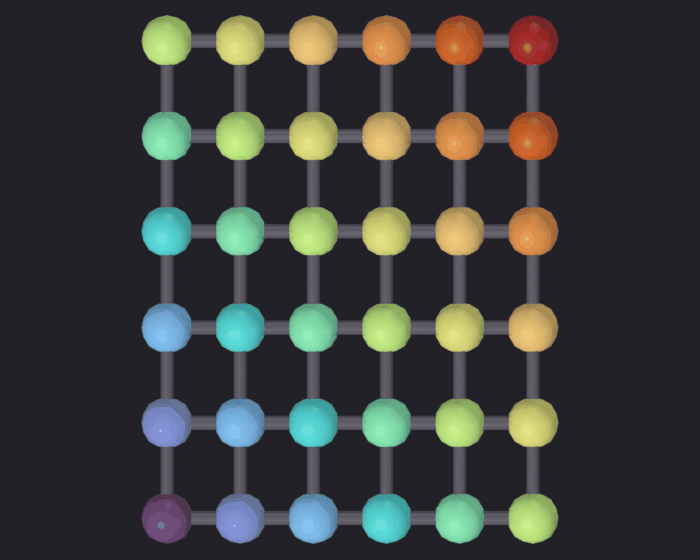

[PASS] grid.png legible — 26.5% ink (healthy range 0.5–60%)


In [12]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import LineString, Point

grid = [(x, y) for x in range(6) for y in range(6)]
nodes = gpd.GeoDataFrame(
    {"value": [x + y for x, y in grid]},
    geometry=[Point(x * 40, y * 40) for x, y in grid],
    index=[f"n{i}" for i in range(len(grid))], crs="EPSG:25830")

pairs = []
for i, (x, y) in enumerate(grid):
    for j, (u, v) in enumerate(grid):
        if j > i and abs(x - u) + abs(y - v) == 1:
            pairs.append((f"n{i}", f"n{j}"))
edges = gpd.GeoDataFrame(
    {"weight": np.arange(len(pairs), dtype=float)},
    geometry=[LineString([nodes.geometry[a], nodes.geometry[b]]) for a, b in pairs],
    index=pd.MultiIndex.from_tuples(pairs), crs="EPSG:25830")

sg.graphs.clear_scene(keep_anchor=False)
anchor = sg.graphs.anchor(39.47, -0.376, scale=0.001, name="Anchor_Test")
mesh = sg.graphs.from_gdf(nodes, edges, name="Grid_Test", ref=anchor,
                          coll="Render_Test")
print(sg.graphs.summary(mesh))

# Worth checking before coloring anything: POINT paints the node spheres and
# leaves the tubes neutral, EDGE paints the tubes. Guessing wrong is how a
# figure comes back monochrome.
print("node_value domain:", sg.render.attribute_domain(mesh, "node_value"))

nb.figure(mesh, "renders/00_smoke/grid", resolution=(700, 560),
          width=650,
          color_attribute="node_value", look='ink')

### And the other engine, separately

That render proves EEVEE works, the source of the figures in notebooks 13 to
09. Section 8's `"SCIGRAPHS" in engines` says only that a class with that
`bl_idname` is registered; an engine whose `render()` raised on the first
call would pass it. Since `SciGraphs.api.thin` moved the edge backbone into
the data,
notebooks 17 and 18 no longer render through this engine, so without this
cell nothing would.

`grid.png` stays on EEVEE as the first plate of a suite that shares one
style, so the GPU engine gets a check of its own: 420x340, no attribute
coloring, the same lattice from the preview's GPU buffers, and all it has to
show is that pixels come back. `node_style='SPHERE'` because the impostors
are real geometry; by the Vulkan note, a `POINT` render here would prove
nothing on the default Linux backend.

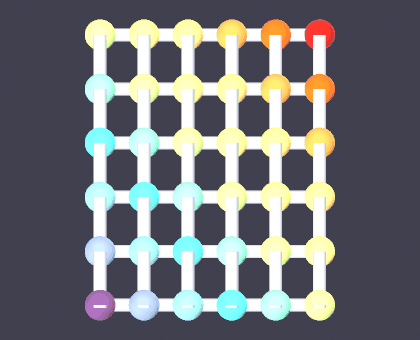

[PASS] the SciGraphs engine renders, not just registers — 30.3% ink from the GPU buffers


True

In [13]:
smoke_path = nb.render_preview(
    mesh, "renders/00_smoke/grid_engine_check", resolution=(420, 340),
    node_style='SPHERE', verbose=False)
nb.show(smoke_path, width=420)
check("the SciGraphs engine renders, not just registers",
      nb.ink(smoke_path) > 0.005,
      f"{nb.ink(smoke_path) * 100:.1f}% ink from the GPU buffers")

## 9 · Sample data in the repository

Some notebooks download from the internet; others work offline from
`examples/`.

In [14]:
resources = {
    "GTFS São Paulo (zip)": nb.repo("examples", "GTFS", "sao_paulo.zip"),
    "Test OD matrix": nb.repo("examples", "city2graph_examples",
                              "od_matrix_test_files", "od_test_edgelist.csv"),
    "Test OD zones": nb.repo("examples", "city2graph_examples",
                             "od_matrix_test_files", "od_test_zones.geojson"),
    "Reproducible pipelines": nb.repo("examples", "pipelines"),
}
for label, path in resources.items():
    exists = path.exists()
    size = f"{path.stat().st_size / 1e6:.1f} MB" if exists and path.is_file() else ""
    print(f"  [{'ok' if exists else '--'}] {label:<26} {size}")

  [ok] GTFS São Paulo (zip)       14.2 MB
  [ok] Test OD matrix             0.0 MB
  [ok] Test OD zones              0.0 MB
  [ok] Reproducible pipelines     


## 10 · Summary

If every `check` says PASS, any notebook will run. Recommended order 01 → 07,
though apart from 06 (which reuses ideas from 04 and 05) they are
independent.

| Notebook | Needs network |
|---|---|
| 01 · Morphology | yes (OSM / Overture) |
| 02 · GTFS transport | no |
| 03 · OD mobility | no |
| 04 · Proximity | yes (OSM) |
| 05 · Metapaths and 15 minutes | yes (OSM) |
| 06 · Functional clustering | yes (OSM) |
| 07 · Reproducible pipelines | no |

In [15]:
print("Environment ready." if not nb.missing() else "Dependencies missing, see above.")

Environment ready.
